# SteamScope：大规模表格处理策略比较

本 Notebook 是 SteamScope 项目的第二个 Notebook，回答的问题是：**面对 1.7GB 的 Steam CSV 数据，应该如何高效、可复现地读取和处理？**

这里的工具比较不是项目主要内容，而是为了给后续 Steam 市场分析选择合适的数据处理策略。本 Notebook 重点比较 `pandas`、`duckdb` 和 `polars` 在实用任务中的表现，并使用 Parquet 作为后续重复分析的中间格式。

## 1. 环境、路径与基准测试设置

本节准备路径、核心字段和简单的计时/内存记录函数。由于本项目不是专业性能评测论文，测试结果只作为课程项目中的处理策略参考。

In [1]:
from pathlib import Path
import gc
import os
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import psutil
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

sns.set_theme(style="whitegrid", context="notebook")
plt.style.use("seaborn-v0_8-whitegrid")

current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == "notebooks" else current_dir
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "archive"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

MAIN_CSV = RAW_DIR / "games_march2025_cleaned.csv"
COMPARE_CSV = RAW_DIR / "games_may2024_cleaned.csv"
SELECTED_PARQUET = PROCESSED_DIR / "steam_march2025_selected.parquet"
YEARLY_PARQUET = PROCESSED_DIR / "steam_march2025_yearly_summary.parquet"

analysis_columns = [
    "appid", "name", "release_date", "price", "windows", "mac", "linux",
    "genres", "categories", "tags", "positive", "negative", "recommendations",
    "peak_ccu", "average_playtime_forever", "num_reviews_total", "pct_pos_total",
]

if not MAIN_CSV.exists():
    raise FileNotFoundError(f"缺少主分析文件：{MAIN_CSV}")

process = psutil.Process(os.getpid())
benchmark_records = []

def rss_mb():
    return process.memory_info().rss / (1024 ** 2)


def run_benchmark(tool, task, func):
    # 简单记录耗时和 RSS 变化。RSS 不是严格峰值内存，只作为近似参考。
    gc.collect()
    before_mem = rss_mb()
    start = time.perf_counter()
    result = func()
    elapsed = time.perf_counter() - start
    after_mem = rss_mb()
    record = {
        "tool": tool,
        "task": task,
        "elapsed_sec": round(elapsed, 4),
        "rss_before_mb": round(before_mem, 2),
        "rss_after_mb": round(after_mem, 2),
        "rss_delta_mb": round(after_mem - before_mem, 2),
    }
    if isinstance(result, dict):
        record.update(result)
    benchmark_records.append(record)
    print(record)
    return result

print("Main CSV:", MAIN_CSV)
print("File size MB:", round(MAIN_CSV.stat().st_size / (1024 ** 2), 2))

Main CSV: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/raw/archive/games_march2025_cleaned.csv
File size MB: 446.93


## 2. 测试任务设计

本 Notebook 不做过重的五工具跑分，而是围绕后续分析真正需要的任务设计三类测试：

1. 选列读取：只读取后续分析需要的核心字段。
2. 年度聚合：按发行年份统计游戏数量、价格、评论、热度等指标。
3. Parquet 转换与读取：把 CSV 中常用字段转成列式格式，提升后续重复分析效率。

## 3. 选列读取对比：pandas、DuckDB、Polars

大 CSV 不应该默认整表读取。这里比较三种工具读取相同核心字段的耗时和近似内存变化。

In [2]:
def pandas_read_selected():
    df = pd.read_csv(MAIN_CSV, usecols=analysis_columns)
    return {"rows": len(df), "columns": df.shape[1]}


def duckdb_read_selected():
    cols = ", ".join([f'"{col}"' for col in analysis_columns])
    query = f"""
        SELECT {cols}
        FROM read_csv_auto('{MAIN_CSV.as_posix()}', ignore_errors=true)
    """
    df = duckdb.sql(query).df()
    return {"rows": len(df), "columns": df.shape[1]}


def polars_read_selected():
    df = pl.scan_csv(MAIN_CSV).select(analysis_columns).collect()
    return {"rows": df.height, "columns": df.width}

run_benchmark("pandas", "selected_column_read", pandas_read_selected)
run_benchmark("duckdb", "selected_column_read", duckdb_read_selected)
run_benchmark("polars", "selected_column_read", polars_read_selected)

benchmark_df = pd.DataFrame(benchmark_records)
display(benchmark_df)

{'tool': 'pandas', 'task': 'selected_column_read', 'elapsed_sec': 1.516, 'rss_before_mb': 268.05, 'rss_after_mb': 484.16, 'rss_delta_mb': 216.11, 'rows': 89618, 'columns': 17}


{'tool': 'duckdb', 'task': 'selected_column_read', 'elapsed_sec': 1.0428, 'rss_before_mb': 487.81, 'rss_after_mb': 703.67, 'rss_delta_mb': 215.86, 'rows': 89618, 'columns': 17}
{'tool': 'polars', 'task': 'selected_column_read', 'elapsed_sec': 0.1616, 'rss_before_mb': 703.67, 'rss_after_mb': 823.58, 'rss_delta_mb': 119.91, 'rows': 89618, 'columns': 17}


,tool,task,elapsed_sec,rss_before_mb,rss_after_mb,rss_delta_mb,rows,columns
0,pandas,selected_column_read,1.5160,268.05,484.16,216.11,89618,17
1,duckdb,selected_column_read,1.0428,487.81,703.67,215.86,89618,17
2,polars,selected_column_read,0.1616,703.67,823.58,119.91,89618,17


选列读取测试可以体现大表格处理的一个基本原则：不是所有任务都需要读取全部字段，尤其是长文本字段会显著增加 I/O 和内存压力。

## 4. 年度聚合对比

Steam 数据包含 `release_date`，后续会频繁做发行年份趋势分析。本节比较三种工具完成“按年份聚合”的能力。

In [3]:
agg_columns = ["release_date", "price", "positive", "negative", "recommendations", "peak_ccu", "num_reviews_total", "pct_pos_total"]


def pandas_yearly_aggregation():
    df = pd.read_csv(MAIN_CSV, usecols=agg_columns)
    df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year
    numeric_cols = ["price", "positive", "negative", "recommendations", "peak_ccu", "num_reviews_total", "pct_pos_total"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    result = (
        df.dropna(subset=["release_year"])
        .groupby("release_year", as_index=False)
        .agg(
            game_count=("release_date", "count"),
            avg_price=("price", "mean"),
            avg_positive=("positive", "mean"),
            avg_peak_ccu=("peak_ccu", "mean"),
            avg_pct_pos_total=("pct_pos_total", "mean"),
        )
        .sort_values("release_year")
    )
    return {"rows": len(result), "columns": result.shape[1]}


def duckdb_yearly_aggregation():
    query = f"""
        SELECT
            year(try_cast(release_date AS DATE)) AS release_year,
            count(*) AS game_count,
            avg(try_cast(price AS DOUBLE)) AS avg_price,
            avg(try_cast(positive AS DOUBLE)) AS avg_positive,
            avg(try_cast(peak_ccu AS DOUBLE)) AS avg_peak_ccu,
            avg(try_cast(pct_pos_total AS DOUBLE)) AS avg_pct_pos_total
        FROM read_csv_auto('{MAIN_CSV.as_posix()}', ignore_errors=true)
        WHERE try_cast(release_date AS DATE) IS NOT NULL
        GROUP BY 1
        ORDER BY 1
    """
    result = duckdb.sql(query).df()
    return {"rows": len(result), "columns": result.shape[1]}


def polars_yearly_aggregation():
    result = (
        pl.scan_csv(MAIN_CSV)
        .select(agg_columns)
        .with_columns([
            pl.col("release_date").str.to_date(strict=False).dt.year().alias("release_year"),
            pl.col("price").cast(pl.Float64, strict=False),
            pl.col("positive").cast(pl.Float64, strict=False),
            pl.col("peak_ccu").cast(pl.Float64, strict=False),
            pl.col("pct_pos_total").cast(pl.Float64, strict=False),
        ])
        .filter(pl.col("release_year").is_not_null())
        .group_by("release_year")
        .agg([
            pl.len().alias("game_count"),
            pl.col("price").mean().alias("avg_price"),
            pl.col("positive").mean().alias("avg_positive"),
            pl.col("peak_ccu").mean().alias("avg_peak_ccu"),
            pl.col("pct_pos_total").mean().alias("avg_pct_pos_total"),
        ])
        .sort("release_year")
        .collect()
    )
    return {"rows": result.height, "columns": result.width}

run_benchmark("pandas", "yearly_aggregation_from_csv", pandas_yearly_aggregation)
run_benchmark("duckdb", "yearly_aggregation_from_csv", duckdb_yearly_aggregation)
run_benchmark("polars", "yearly_aggregation_from_csv", polars_yearly_aggregation)

benchmark_df = pd.DataFrame(benchmark_records)
display(benchmark_df)

{'tool': 'pandas', 'task': 'yearly_aggregation_from_csv', 'elapsed_sec': 1.3344, 'rss_before_mb': 823.89, 'rss_after_mb': 933.73, 'rss_delta_mb': 109.84, 'rows': 27, 'columns': 6}


{'tool': 'duckdb', 'task': 'yearly_aggregation_from_csv', 'elapsed_sec': 0.9348, 'rss_before_mb': 933.73, 'rss_after_mb': 944.02, 'rss_delta_mb': 10.28, 'rows': 27, 'columns': 6}
{'tool': 'polars', 'task': 'yearly_aggregation_from_csv', 'elapsed_sec': 0.1982, 'rss_before_mb': 943.97, 'rss_after_mb': 999.77, 'rss_delta_mb': 55.8, 'rows': 27, 'columns': 6}


,tool,task,elapsed_sec,rss_before_mb,rss_after_mb,rss_delta_mb,rows,columns
0,pandas,selected_column_read,1.5160,268.05,484.16,216.11,89618,17
1,duckdb,selected_column_read,1.0428,487.81,703.67,215.86,89618,17
2,polars,selected_column_read,0.1616,703.67,823.58,119.91,89618,17
3,pandas,yearly_aggregation_from_csv,1.3344,823.89,933.73,109.84,27,6
4,duckdb,yearly_aggregation_from_csv,0.9348,933.73,944.02,10.28,27,6
5,polars,yearly_aggregation_from_csv,0.1982,943.97,999.77,55.80,27,6


年度聚合是后续市场趋势分析的核心任务。相比整表读取后再处理，DuckDB 和 Polars 都可以更自然地表达“按需扫描 + 聚合”的思路。

## 5. CSV 转 Parquet：为后续 Notebook 准备中间数据

CSV 适合作为原始交换格式，但重复分析时不够高效。Parquet 是列式存储格式，适合按列读取和重复分析。本节把主分析文件中的核心字段转换为 Parquet。

{'tool': 'polars', 'task': 'csv_selected_columns_to_parquet', 'elapsed_sec': 0.2505, 'rss_before_mb': 999.8, 'rss_after_mb': 974.12, 'rss_delta_mb': -25.67, 'rows': 89618, 'columns': 17, 'output_file': 'steam_march2025_selected.parquet', 'output_size_mb': 6.01}


,file_type,size_mb
0,original_csv,446.93
1,selected_parquet,6.01


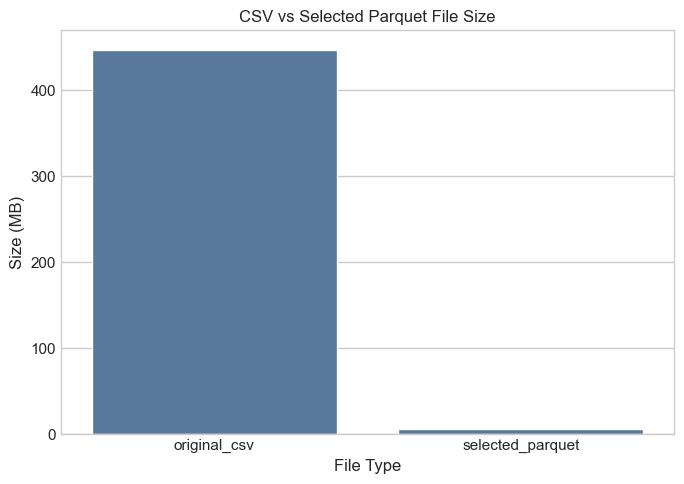

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/03_csv_vs_selected_parquet_size.png


In [4]:
def create_selected_parquet():
    df = pl.scan_csv(MAIN_CSV).select(analysis_columns).collect()
    df.write_parquet(SELECTED_PARQUET)
    return {
        "rows": df.height,
        "columns": df.width,
        "output_file": SELECTED_PARQUET.name,
        "output_size_mb": round(SELECTED_PARQUET.stat().st_size / (1024 ** 2), 2),
    }

run_benchmark("polars", "csv_selected_columns_to_parquet", create_selected_parquet)

csv_size_mb = MAIN_CSV.stat().st_size / (1024 ** 2)
parquet_size_mb = SELECTED_PARQUET.stat().st_size / (1024 ** 2)
size_compare = pd.DataFrame({
    "file_type": ["original_csv", "selected_parquet"],
    "size_mb": [csv_size_mb, parquet_size_mb],
})
display(size_compare.round(2))

plt.figure(figsize=(7, 5))
sns.barplot(data=size_compare, x="file_type", y="size_mb", color="#4C78A8")
plt.title("CSV vs Selected Parquet File Size")
plt.xlabel("File Type")
plt.ylabel("Size (MB)")
plt.tight_layout()
figure_path = FIGURES_DIR / "03_csv_vs_selected_parquet_size.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

Parquet 文件只保留后续分析常用字段，因此文件体积会显著小于原始 CSV。这个文件不是替代原始数据，而是后续分析的高效中间层。

## 6. Parquet 读取对比

生成 Parquet 后，再比较 Pandas、DuckDB 和 Polars 从 Parquet 读取数据的速度。这个步骤用于判断后续 Notebook 是否应该优先读取 Parquet。

{'tool': 'pandas', 'task': 'read_selected_parquet', 'elapsed_sec': 0.1562, 'rss_before_mb': 977.91, 'rss_after_mb': 1024.8, 'rss_delta_mb': 46.89, 'rows': 89618, 'columns': 17}
{'tool': 'duckdb', 'task': 'read_selected_parquet', 'elapsed_sec': 0.1036, 'rss_before_mb': 1024.8, 'rss_after_mb': 1012.22, 'rss_delta_mb': -12.58, 'rows': 89618, 'columns': 17}
{'tool': 'polars', 'task': 'read_selected_parquet', 'elapsed_sec': 0.0398, 'rss_before_mb': 1012.25, 'rss_after_mb': 1031.39, 'rss_delta_mb': 19.14, 'rows': 89618, 'columns': 17}


,tool,task,elapsed_sec,rss_before_mb,rss_after_mb,rss_delta_mb,rows,columns,output_file,output_size_mb
0,pandas,selected_column_read,1.5160,268.05,484.16,216.11,89618,17,NaN,NaN
1,duckdb,selected_column_read,1.0428,487.81,703.67,215.86,89618,17,NaN,NaN
2,polars,selected_column_read,0.1616,703.67,823.58,119.91,89618,17,NaN,NaN
3,pandas,yearly_aggregation_from_csv,1.3344,823.89,933.73,109.84,27,6,NaN,NaN
4,duckdb,yearly_aggregation_from_csv,0.9348,933.73,944.02,10.28,27,6,NaN,NaN
5,polars,yearly_aggregation_from_csv,0.1982,943.97,999.77,55.80,27,6,NaN,NaN
6,polars,csv_selected_columns_to_parquet,0.2505,999.80,974.12,-25.67,89618,17,steam_march2025_selected.parquet,6.01
7,pandas,read_selected_parquet,0.1562,977.91,1024.80,46.89,89618,17,NaN,NaN
8,duckdb,read_selected_parquet,0.1036,1024.80,1012.22,-12.58,89618,17,NaN,NaN
9,polars,read_selected_parquet,0.0398,1012.25,1031.39,19.14,89618,17,NaN,NaN


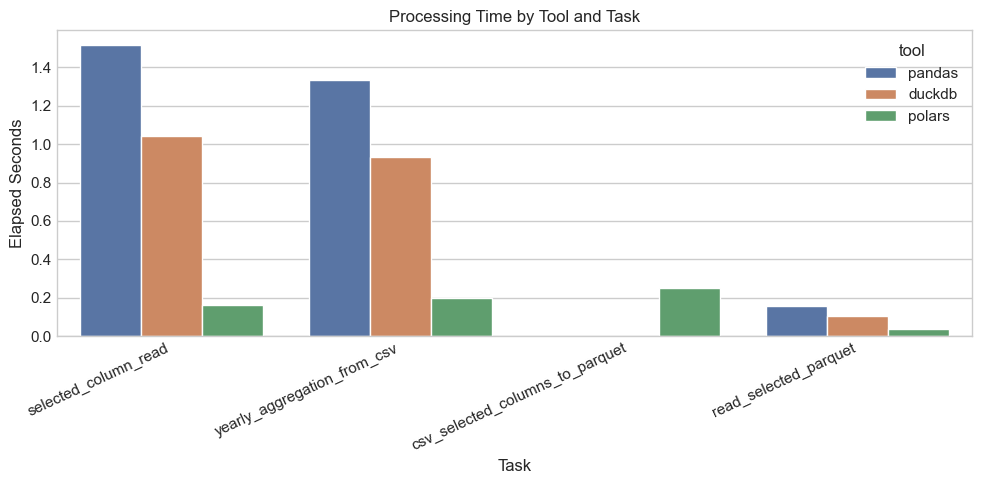

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/04_processing_time_by_tool_and_task.png


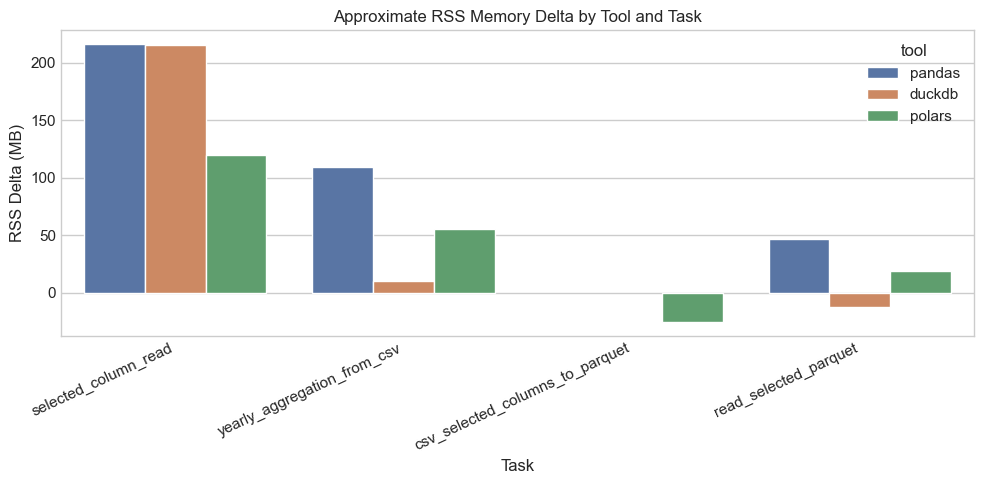

Saved figure: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/figures/05_memory_delta_by_tool_and_task.png


In [5]:
def pandas_read_parquet():
    df = pd.read_parquet(SELECTED_PARQUET)
    return {"rows": len(df), "columns": df.shape[1]}


def duckdb_read_parquet():
    df = duckdb.sql(f"SELECT * FROM read_parquet('{SELECTED_PARQUET.as_posix()}')").df()
    return {"rows": len(df), "columns": df.shape[1]}


def polars_read_parquet():
    df = pl.scan_parquet(SELECTED_PARQUET).collect()
    return {"rows": df.height, "columns": df.width}

run_benchmark("pandas", "read_selected_parquet", pandas_read_parquet)
run_benchmark("duckdb", "read_selected_parquet", duckdb_read_parquet)
run_benchmark("polars", "read_selected_parquet", polars_read_parquet)

benchmark_df = pd.DataFrame(benchmark_records)
display(benchmark_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_df, x="task", y="elapsed_sec", hue="tool")
plt.title("Processing Time by Tool and Task")
plt.xlabel("Task")
plt.ylabel("Elapsed Seconds")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
figure_path = FIGURES_DIR / "04_processing_time_by_tool_and_task.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

plt.figure(figsize=(10, 5))
sns.barplot(data=benchmark_df, x="task", y="rss_delta_mb", hue="tool")
plt.title("Approximate RSS Memory Delta by Tool and Task")
plt.xlabel("Task")
plt.ylabel("RSS Delta (MB)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
figure_path = FIGURES_DIR / "05_memory_delta_by_tool_and_task.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved figure:", figure_path)

需要注意：这里的内存记录是进程 RSS 的近似变化，不是严格峰值内存。因此它适合做课程项目中的策略说明，但不应该被解释成严谨的硬件性能评测。

## 7. 保存基准结果和年度汇总

为了让后续报告可以复用，本节保存工具对比结果和年度汇总表。年度汇总表后续可以直接用于市场趋势分析。

In [6]:
benchmark_output = PROCESSED_DIR / "large_table_processing_benchmark.csv"
benchmark_df.to_csv(benchmark_output, index=False)
print("Saved benchmark table:", benchmark_output)

# 使用 DuckDB 从 CSV 生成年度汇总，再保存为 Parquet
query = f"""
    SELECT
        year(try_cast(release_date AS DATE)) AS release_year,
        count(*) AS game_count,
        avg(try_cast(price AS DOUBLE)) AS avg_price,
        avg(try_cast(positive AS DOUBLE)) AS avg_positive,
        avg(try_cast(negative AS DOUBLE)) AS avg_negative,
        avg(try_cast(recommendations AS DOUBLE)) AS avg_recommendations,
        avg(try_cast(peak_ccu AS DOUBLE)) AS avg_peak_ccu,
        avg(try_cast(pct_pos_total AS DOUBLE)) AS avg_pct_pos_total,
        avg(try_cast(num_reviews_total AS DOUBLE)) AS avg_num_reviews_total
    FROM read_csv_auto('{MAIN_CSV.as_posix()}', ignore_errors=true)
    WHERE try_cast(release_date AS DATE) IS NOT NULL
    GROUP BY 1
    ORDER BY 1
"""
yearly_summary = duckdb.sql(query).df()
yearly_summary.to_parquet(YEARLY_PARQUET, index=False)
display(yearly_summary.tail(10).round(3))
print("Saved yearly summary:", YEARLY_PARQUET)

Saved benchmark table: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/large_table_processing_benchmark.csv


,release_year,game_count,avg_price,avg_positive,avg_negative,avg_recommendations,avg_peak_ccu,avg_pct_pos_total,avg_num_reviews_total
17,2016,4160,7.174,2169.163,303.315,1735.626,95.551,58.789,1896.450
18,2017,5967,6.777,1616.998,397.918,1200.589,147.555,49.378,1765.128
19,2018,7443,6.330,1416.634,209.588,1243.097,89.395,45.284,1290.819
20,2019,6146,7.209,1183.628,178.365,942.629,43.396,45.010,1181.567
21,2020,8568,6.629,1313.456,213.244,1088.451,70.104,46.496,1348.960
22,2021,8294,7.584,812.420,155.607,725.605,46.656,47.093,981.814
23,2022,9158,7.679,698.895,144.465,635.063,35.684,45.418,782.314
24,2023,12735,7.428,489.307,91.421,456.373,34.266,41.321,609.614
25,2024,18282,7.461,437.121,71.553,412.445,38.508,39.015,531.033
26,2025,3573,7.704,302.613,50.081,272.850,391.996,31.942,376.508


Saved yearly summary: /Users/situozhang/Documents/大数据处理技术/Ultimate_Game_Insights/data/processed/steam_march2025_yearly_summary.parquet


## 8. 处理策略结论

基于本 Notebook 的实践测试，后续项目建议采用以下策略：

1. 原始 CSV 保留在 `data/raw/archive/`，作为不可替代的原始数据来源。
2. 不在每个 Notebook 中反复读取全部 CSV，而是优先进行选列读取。
3. 对重复使用的核心字段，转换成 Parquet 存放在 `data/processed/`。
4. `pandas` 适合小规模抽样、展示和常规分析；`duckdb` 适合直接对 CSV/Parquet 做 SQL 查询和聚合；`polars` 适合高性能 DataFrame 和批量转换。
5. 后续清洗与特征工程可以优先基于 Parquet 中间文件，同时保留回到原始 CSV 的能力。

这使项目既能体现课程中“大量级表格数据处理工具”的内容，又不会让工具跑分喧宾夺主。